<a href="https://colab.research.google.com/github/WeAreHuman/SimpleLogisticRegression/blob/main/SimpleLogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
trans = pd.read_csv('https://raw.githubusercontent.com/WeAreHuman/SimpleLogisticRegression/refs/heads/main/data/transactions.csv')
sessions = pd.read_csv('https://raw.githubusercontent.com/WeAreHuman/SimpleLogisticRegression/refs/heads/main/data/sessions.csv')

st=trans.merge(sessions, on="session_id",how="inner")

<Axes: >

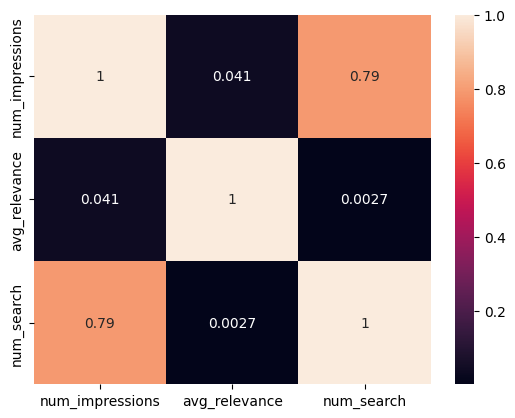

In [61]:
X = trans[['num_impressions', 'avg_relevance', 'num_search']]
sns.heatmap(X.corr(), annot=True)

In [57]:
trans.groupby(['score','train','test']).size().reset_index(name='cnt')

,score,train,test,cnt
0,False,True,False,31287
1,True,False,False,10000
2,True,False,True,5000


In [35]:
#trying to use the date column as a feature by getting the day of the week
st['session_dt'] = pd.to_datetime(st['session_dt'])
st['day_of_week'] = st['session_dt'].dt.weekday

# Feature Engineering

In [63]:
g= st[['session_dt',"num_impressions"]].sort_values("session_dt")
 g['session_dt'] - g['session_dt'].iloc[0]

46287

In [68]:
def build_user_features(split_df: pd.DataFrame) -> pd.DataFrame:
  ref_date = split_df['session_dt'].max()
  agg = split_df.groupby('user_id').agg(
      total_impressions = ('num_impressions','sum'),
      avg_relevance_mean = ('avg_relevance','mean'),
      search_intensity = ('num_search', 'sum'),
      num_sessions = ('session_id','count'),
      last_session_dt = ('session_dt','max'),
      conversion_user = ("conversion", lambda s: s.max())
  ).reset_index()

  agg["last_session_recency"] = (ref_date - agg["last_session_dt"]).dt.days.astype(float)
  return agg[["user_id","total_impressions","avg_relevance_mean","search_intensity", "num_sessions","last_session_recency","conversion_user"]]

# Model Training

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [70]:
# --- 3) Train/Test user tables (no leakage) ---
train_users = build_user_features(st[st["train"]])
test_users  = build_user_features(st[st["test"]])

feat_cols = ["total_impressions","avg_relevance_mean","search_intensity","num_sessions","last_session_recency"]

X_train = train_users[feat_cols].values
y_train = train_users["conversion_user"].astype(int).values

X_test  = test_users[feat_cols].values
y_test  = test_users["conversion_user"].astype(int).values

In [71]:
# --- 4) Fit & evaluate ---
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [72]:
print("Test Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Coefficients:")
for f, c in zip(feat_cols, model.coef_[0]):
    print(f"{f:22s} {c: .4f}")

Test Accuracy: 0.514
Coefficients:
total_impressions       0.7367
avg_relevance_mean      8.3040
search_intensity        0.0129
num_sessions           -0.8384
last_session_recency    0.0025


In [73]:
# If you want a tidy predictions frame per user_id:
pred_df = test_users[["user_id"]].copy()
pred_df["pred_conv"] = (y_pred == 1)
print(pred_df.head())

      user_id  pred_conv
0  00CFAV3zZI      False
1  00LVEpIPZU      False
2  00ykE3lwb7      False
3  02VUyEv07A      False
4  033hsgyeLn      False


In [53]:
train = st[(st['test']==False)]
X_train = train[['day_of_week','num_impressions', 'avg_relevance','num_search']]
y_train = train[['conversion']].astype(int)

val = st[(st['train']==False) & (st['test']==False)]
X_val = val[['day_of_week','num_impressions', 'avg_relevance','num_search']]
y_val = val[['conversion']].astype(int)


In [40]:
type(X_train)

pandas.core.frame.DataFrame

In [54]:
model = LogisticRegression()
model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [43]:
y_val_pred = model.predict(X_val)

In [44]:
accuracy_score(y_val, y_val_pred)

0.9976

In [45]:
confusion_matrix(y_val,y_val_pred)

array([[9976,   24],
       [   0,    0]])

In [48]:
classification_report(y_val,y_val_pred)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


'              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00     10000\n           1       0.00      0.00      0.00         0\n\n    accuracy                           1.00     10000\n   macro avg       0.50      0.50      0.50     10000\nweighted avg       1.00      1.00      1.00     10000\n'

# Model Testing

In [49]:
test = st[st['test']==True]
X_test = test[['day_of_week','num_impressions', 'avg_relevance','num_search']]
y_test = test[['conversion']].astype(int)

In [60]:
test

,conversion,session_id,session_dt,num_impressions,avg_relevance,num_search,train,score,test,user_id,day_of_week
10000,True,DdehvHesMsRRYwL,2018-08-09,4,0.884369,3,False,True,True,OO3Djzyjcv,3
10001,True,uZZjZEGt7bIKHlE,2018-09-04,5,0.965662,3,False,True,True,bXrMVTz1VX,1
10002,True,bajXCgWVaaoBUSW,2018-08-12,7,0.995262,2,False,True,True,cm9PE3tu1l,6
10003,True,ip1XuvsrjecqPcQ,2018-09-15,9,0.339499,3,False,True,True,zA4Fq7HxWm,5
10004,True,mLblvZPGOsa5cWT,2018-08-16,4,0.703191,3,False,True,True,wtvQCvGKkC,3
...,...,...,...,...,...,...,...,...,...,...,...
14995,True,Fyj1OWmsGUXYsR8,2018-08-03,10,0.642112,4,False,True,True,Vc9KWZEsQQ,4
14996,True,CHNVe5elRXejLOt,2018-08-20,4,0.644380,3,False,True,True,XfNuTXKbBE,0
14997,True,RpfEgk810QMJaCx,2018-08-08,7,0.334254,3,False,True,True,F7qCMvfKta,2
14998,False,KMp7BnQQhUNTBvl,2018-09-08,4,0.884945,1,False,True,True,a0DkY4UJQV,5


In [55]:
y_test_pred = model.predict(X_test)

In [56]:
accuracy_score(y_test,y_test_pred)

0.514